<>:70: SyntaxWarning: invalid escape sequence '\d'
<>:74: SyntaxWarning: invalid escape sequence '\d'
<>:70: SyntaxWarning: invalid escape sequence '\d'
<>:74: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_710/3499691783.py:70: SyntaxWarning: invalid escape sequence '\d'
  df['Time to Resolution'] = df['Time to Resolution'].str.extract('(\d+)')
/tmp/ipykernel_710/3499691783.py:74: SyntaxWarning: invalid escape sequence '\d'
  df['First Response Time'] = df['First Response Time'].str.extract('(\d+)')


Columns:
 Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

Sample Data:
   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero    

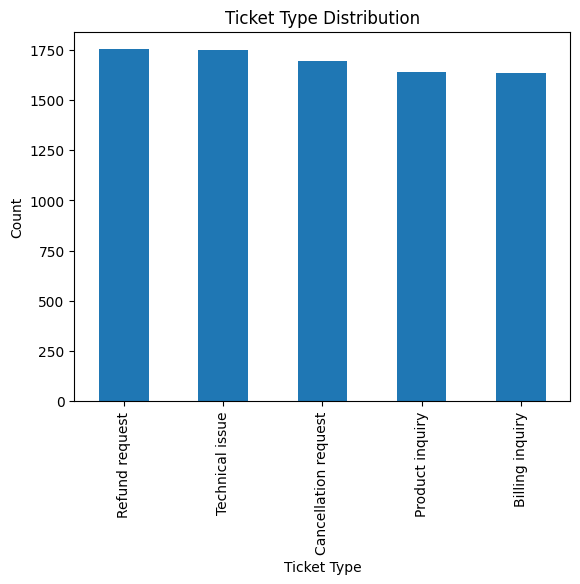

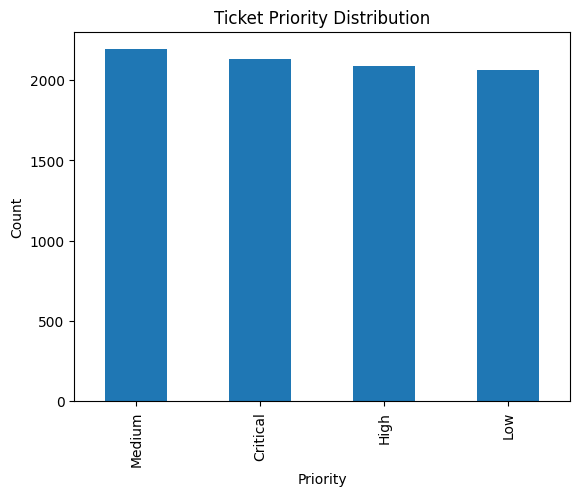

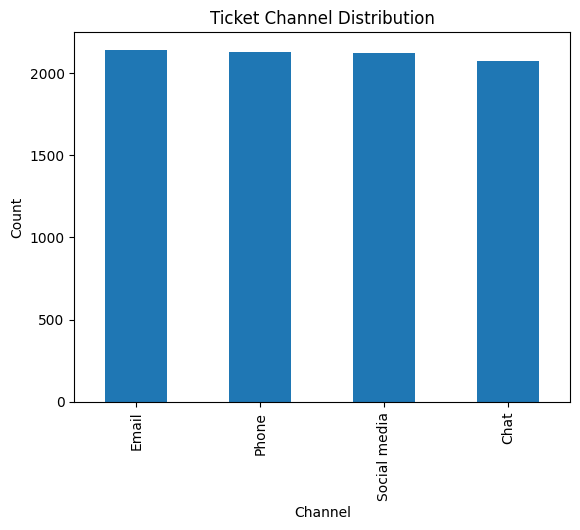

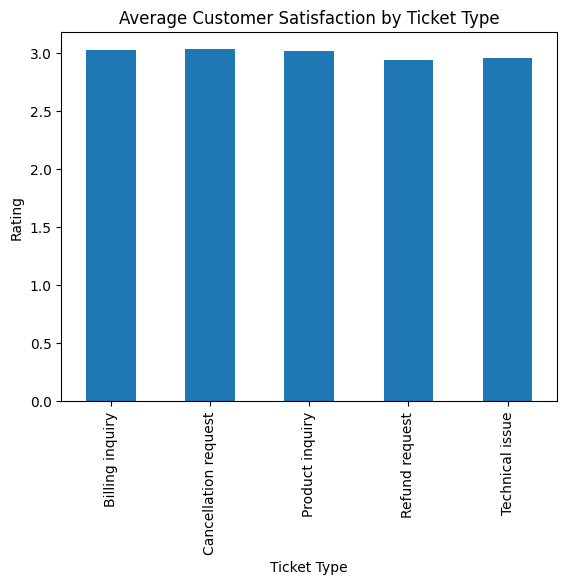


Average Resolution Time by Priority:
Ticket Priority
Critical    2023.0
High        2023.0
Low         2023.0
Medium      2023.0
Name: Time to Resolution, dtype: float64

Average First Response Time by Channel:
Ticket Channel
Chat            2023.0
Email           2023.0
Phone           2023.0
Social media    2023.0
Name: First Response Time, dtype: float64

File saved: classified_tickets.csv


In [10]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("FT2_Dataset.csv", encoding='latin1')

print("Columns:\n", df.columns)
print("\nSample Data:")
print(df.head())

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['clean_text'] = df['Ticket Description'].apply(clean_text)

X_text = df['clean_text']
y = df['Ticket Type']

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(X_text)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

df['Predicted_Ticket_Type'] = model.predict(X)

plt.figure()
df['Ticket Type'].value_counts().plot(kind='bar')
plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Count")
plt.show()

plt.figure()
df['Ticket Priority'].value_counts().plot(kind='bar')
plt.title("Ticket Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.show()

plt.figure()
df['Ticket Channel'].value_counts().plot(kind='bar')
plt.title("Ticket Channel Distribution")
plt.xlabel("Channel")
plt.ylabel("Count")
plt.show()

plt.figure()
df.groupby('Ticket Type')['Customer Satisfaction Rating'].mean().plot(kind='bar')
plt.title("Average Customer Satisfaction by Ticket Type")
plt.ylabel("Rating")
plt.show()

df['Time to Resolution'] = df['Time to Resolution'].astype(str)
df['Time to Resolution'] = df['Time to Resolution'].str.extract('(\d+)')
df['Time to Resolution'] = pd.to_numeric(df['Time to Resolution'], errors='coerce')

df['First Response Time'] = df['First Response Time'].astype(str)
df['First Response Time'] = df['First Response Time'].str.extract('(\d+)')
df['First Response Time'] = pd.to_numeric(df['First Response Time'], errors='coerce')

print("\nAverage Resolution Time by Priority:")
print(df.groupby('Ticket Priority')['Time to Resolution'].mean())

print("\nAverage First Response Time by Channel:")
print(df.groupby('Ticket Channel')['First Response Time'].mean())

df.to_csv("classified_tickets.csv", index=False)

print("\nFile saved: classified_tickets.csv")